---
## ⚠️ IMPORTANT USAGE NOTES

### Changes from Original
This notebook has been modified to use different data sources for the multifidelity inputs. Make sure you:

1. **Have the required data files:**
   - `./data/ice/Antarctic_thickness_1993_2023.pkl` (ice thickness)
   - `./data/ice/Antarctic_SST_1993_2023.pkl` (SST data)
   - `./data/ice/Antarctic_years_1989_2024i.pkl` (original ice concentration data)


---

In [1]:
#import libraries for multifidelity transformer
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
import yaml
import wandb
import pandas as pd
from tqdm import tqdm

# Scientific computing
from scipy.optimize import minimize

# Data handling
import dill
import pickle

# System path for local modules
import sys
sys.path.append('./src/modules')

# Import utility functions from src/modules
from data_wrangle import thin_data, del_leap, get_days_before, window_mean, get_test_set, day_to_date, date_to_day
from dmd_routines import reshape_data2dmd, train_dmd, reshape_Psi2data, eval_dmd, eval_dmd_latent, bootstrap_train_dmd, eval_dmd_ensemble

# Jupyter widgets for interactive elements
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import wandb
import warnings
warnings.filterwarnings("ignore")

# Import multifidelity modules
from multifidelity_transformer.utils.data import MultiFidelityDataset, compute_randomized_SVD
from multifidelity_transformer.models.models_experimental import MultifidelityTransformer
from multifidelity_transformer.utils.training import lr_schedule, run_epoch, model_eval, CustomMSE

# Set device
device = "cpu"
print(f"Using device: {device}")

/Users/giorgioaurina/Desktop/2026_TESI/Ultimo/Progressive-Multifidelity-Learning/./src/modules/data_wrangle.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


Using device: cpu


In [2]:
def plot_data(data, mask=True, x=None, y=None, cmap='viridis', min_max=False):
    """
    Plot batch of shape (N_states, x, y)
    - If data is a list of arrays, create subplots (1, len(data))
    """
    # Handle x and y defaults
    if isinstance(data, list):
        N_states = data[0].shape[0]
    else:
        N_states = data.shape[0]
        
    if x is None: 
        x = np.arange(data[0].shape[2] if isinstance(data, list) else data.shape[2])
    if y is None: 
        y = np.arange(data[0].shape[1] if isinstance(data, list) else data.shape[1])
    
    def plot(i, BATCH_list, mask=True):
        num_plots = len(BATCH_list) if isinstance(BATCH_list, list) else 1
        
        fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
        if num_plots == 1:
            axes = [axes]  # make iterable
        
        for ax_idx, ax in enumerate(axes):
            BATCH = BATCH_list[ax_idx] if isinstance(BATCH_list, list) else BATCH_list
            ax.clear()
            ax.set(adjustable='box', aspect=1) 
            
            if min_max:
                cf = ax.contourf(
                    x, y, np.clip(np.where(~mask, BATCH[i, ...], np.nan), 0, 1),#x, y, np.where(~mask, BATCH[i, ...], np.nan), 
                    cmap=cmap, vmin=0., vmax=1.
                )
            else:
                cf = ax.contourf(
                    x, y, np.where(~mask, BATCH[i, ...], np.nan), 
                    cmap=cmap
                )
            ax.set_title(f'Data {ax_idx} (frame {i})') 
            
            # Link colorbar to cf
            cbar = plt.colorbar(cf, ax=ax)
            cbar.set_label('Value')
        
        plt.tight_layout()
        plt.show()
    
    # Slider for frame index
    i_widget = widgets.IntSlider(
        min=0, max=N_states - 1, step=1, value=0, 
        continuous_update=True, description='Frame'
    )
    
    # Fix data reference
    fixed_data = fixed(data) if isinstance(data, list) else fixed(data)
    
    # Create interactive widget
    w = interactive(
        plot, 
        i=i_widget, 
        BATCH_list=fixed(data), 
        mask=fixed(mask)
    )
    
    return w

'''def plot_data(data, mask = True, x = None, y = None):
    """
    plot batch of shape (N_states, x, y)
    """
    def plot(i, BATCH, mask = True):
        
        fig, ax = plt.subplots()
        ax.set(adjustable='box', aspect=1) 
        ax.contourf(x, y, np.where(~mask, BATCH[i, ...], np.nan) )
        

    if x is None: x = np.arange(data.shape[1])
    if y is None: y = np.arange(data.shape[0])

    i_widget = widgets.IntSlider(min=0, 
                                max=data.shape[0]-1, step=1, value=0, 
                                continuous_update=True, 
                                description = 'f_i(x,y)',
                                )

    w = interactive(plot, 
                    i = i_widget, 
                    BATCH = fixed(data), mask = fixed(mask))
    
    return w'''


'def plot_data(data, mask = True, x = None, y = None):\n    """\n    plot batch of shape (N_states, x, y)\n    """\n    def plot(i, BATCH, mask = True):\n        \n        fig, ax = plt.subplots()\n        ax.set(adjustable=\'box\', aspect=1) \n        ax.contourf(x, y, np.where(~mask, BATCH[i, ...], np.nan) )\n        \n\n    if x is None: x = np.arange(data.shape[1])\n    if y is None: y = np.arange(data.shape[0])\n\n    i_widget = widgets.IntSlider(min=0, \n                                max=data.shape[0]-1, step=1, value=0, \n                                continuous_update=True, \n                                description = \'f_i(x,y)\',\n                                )\n\n    w = interactive(plot, \n                    i = i_widget, \n                    BATCH = fixed(data), mask = fixed(mask))\n    \n    return w'

## 0) OPEN DATA & PREPROCESSING

## Data Loading and Preprocessing Overview

This section loads three Antarctic datasets spanning 1993-2023:

1. **Ice Thickness** (`Antarctic_thickness_1993_2023.pkl`): Daily measurements of ice thickness in meters
2. **Sea Surface Temperature (SST)** (`Antarctic_SST_1993_2023.pkl`): Daily sea surface temperature in °C
3. **Ice Concentration** (`Antarctic_years_1989_2024i.pkl`): Daily fractional ice coverage (0-1)

### Preprocessing Steps:
- **Thinning**: Reduce spatial resolution for computational efficiency
- **Leap day removal**: Standardize to 365-day years for analysis
- **Temporal alignment**: Ensure all datasets cover the same period (1993-2023, 31 years)

In [3]:
# Esempio di caricamento futuro
with open('./data/ice/Antarctic_SST_1993_2023.pkl', 'rb') as f:
    sst_data_, sst_years_ = dill.load(f)

In [4]:
# Esempio di caricamento futuro
with open('./data/ice/Antarctic_thickness_1993_2023.pkl', 'rb') as f:
    thickness_data_, thickness_years_ = dill.load(f)

# Ora thickness_data è una lista compatibile col tuo codice
# Esempio: w0 = plot_data(thickness_data[0], mask=mask_land_, ...)

In [6]:
with open('./data/ice/Antarctic_years_1989_2024i.pkl', 'rb') as f:
    mask_land_, mask_ice_, data_, data_mean_month_, data_mean_week_, x_, y_ = dill.load(f)

In [7]:
len(data_)

36

In [8]:
thin = 1
window = 1
data, data_mean_month, data_mean_week, x, y, mask_ice, mask_land = \
    thin_data(thin, data_, data_mean_month_, data_mean_week_, x_, y_, mask_ice_, mask_land_)

data = del_leap(data)
del data_, data_mean_month_, data_mean_week_
ny, nx = data[0].shape[1:]

mask_ice_.shape, mask_ice.shape

  0%|          | 0/36 [00:00<?, ?it/s]

((432, 432), (432, 432))

In [9]:
# Apply the same thinning and del_leap to thickness and SST data
# thin_data returns a list of processed arguments, so unpack with [0]
thickness_data = thin_data(thin, thickness_data_)[0]
sst_data = thin_data(thin, sst_data_)[0]

# Remove leap days (del_leap returns the processed list directly)
thickness_data = del_leap(thickness_data)
sst_data = del_leap(sst_data)

print(f"After preprocessing:")
print(f"  thickness_data: {len(thickness_data)} years")
print(f"  sst_data: {len(sst_data)} years")
print(f"  data: {len(data)} years")
if len(thickness_data) > 0:
    print(f"  thickness_data[0].shape: {thickness_data[0].shape}")
if len(sst_data) > 0:
    print(f"  sst_data[0].shape: {sst_data[0].shape}")

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

After preprocessing:
  thickness_data: 31 years
  sst_data: 31 years
  data: 36 years
  thickness_data[0].shape: (365, 432, 432)
  sst_data[0].shape: (365, 432, 432)


- `data_` is a list of 36 years where each one has dimension (n_day, nx, ny), where n_day = 365, nx=ny=432
- `mask_land_` is a boolean mask to indicate where there is land or water
- `data_mean_month_` and `data_mean_week_` have monthly and weekly time frequency (instead of daily)

`thin_data` reduce spatial dimensionality to the degrees of freedom where we do not have land\

In [10]:
len(data)

36

In [11]:
data = data[4:-1]

In [12]:
len(data)

31

In [13]:
w0 = plot_data([thickness_data[0], sst_data[0], data[0]], 
              mask = mask_land, 
              x = x, 
              y = y)

display(w0)

interactive(children=(IntSlider(value=0, description='Frame', max=364), Output()), _dom_classes=('widget-inter…

# Analysis: Correlations, Trends, and Timeseries

This section performs comprehensive statistical analysis on the Antarctic data:
- Temporal correlations between variables
- Spatial correlation maps
- Linear trends and warming/cooling rates
- Timeseries visualization with trend lines

---

## Data Preparation: Stack and Average

Before analyzing correlations and trends, we convert the yearly data lists into continuous arrays:
- **Daily data**: All 365 days × 31 years stacked into continuous timeseries
- **Yearly averages**: Single mean value per year (31 values)

This creates two datasets:
1. **High-frequency (daily)**: Better for detecting short-term variability
2. **Low-frequency (yearly)**: Better for detecting long-term climate trends

Both will be used in subsequent analyses for comparison.

In [ ]:
for i in range(31):
    print(f"Year {i}: SST min={sst_data[i].min()}, max={sst_data[i].max()}, Thickness min={thickness_data[i].min()}, max={thickness_data[i].max()}")


Year 0: SST min=-2.7981700897216797, max=13.724709510803223, Thickness min=0.0, max=3.688829183578491
Year 1: SST min=-2.5739505290985107, max=15.076221466064453, Thickness min=0.0, max=4.418391704559326
Year 2: SST min=-2.5936572551727295, max=13.937874794006348, Thickness min=0.0, max=4.838769912719727
Year 3: SST min=-2.781277894973755, max=15.215551376342773, Thickness min=0.0, max=4.237930774688721
Year 4: SST min=-2.9366419315338135, max=13.962873458862305, Thickness min=0.0, max=4.047595977783203
Year 5: SST min=-2.9185476303100586, max=14.158512115478516, Thickness min=0.0, max=4.135852813720703
Year 6: SST min=-2.9100091457366943, max=15.363353729248047, Thickness min=0.0, max=3.987471103668213
Year 7: SST min=-2.9227564334869385, max=14.530599594116211, Thickness min=0.0, max=4.535666465759277
Year 8: SST min=-2.689723014831543, max=15.024587631225586, Thickness min=0.0, max=4.270290851593018
Year 9: SST min=-2.7844414710998535, max=15.564324378967285, Thickness min=0.0, max=

IndexError: list index out of range

## 1. Data Preparation for Analysis

First, we need to reshape our data into formats suitable for correlation and trend analysis.

In [14]:
# Convert lists of annual data to single continuous arrays
# Stack all years together: (n_years, n_days, ny, nx) -> (n_years*n_days, ny, nx)

def stack_years(data_list):
    """Stack list of yearly arrays into single continuous array"""
    return np.concatenate(data_list, axis=0)

# Stack all three datasets
thickness_full = stack_years(thickness_data)
sst_full = stack_years(sst_data)
ice_full = stack_years(data)

print(f"Thickness data shape: {thickness_full.shape}")
print(f"SST data shape: {sst_full.shape}")
print(f"Ice concentration shape: {ice_full.shape}")
print(f"Total days: {thickness_full.shape[0]}")
print(f"Total years: {len(thickness_data)}")

Thickness data shape: (11315, 432, 432)
SST data shape: (11315, 432, 432)
Ice concentration shape: (11315, 432, 432)
Total days: 11315
Total years: 31


## 2. Spatial Correlation Maps

Compute pixel-wise correlations between variables across time.

### Spatial Correlation Analysis

Correlation maps show where variables are linked across the Antarctic region. For each pixel:
- **High positive correlation** (red): Variables increase/decrease together
- **High negative correlation** (blue): Variables move in opposite directions
- **Near zero** (white): No consistent relationship

These maps reveal spatial patterns: Do thickness changes align with SST everywhere, or only in specific regions?

In [15]:
def compute_spatial_correlation(data1, data2, mask=None):
    """
    Compute pixel-wise correlation between two spatiotemporal datasets
    
    Args:
        data1, data2: Arrays of shape (n_time, ny, nx)
        mask: Boolean mask (True where land)
    
    Returns:
        Correlation map of shape (ny, nx)
    """
    ny, nx = data1.shape[1], data1.shape[2]
    corr_map = np.full((ny, nx), np.nan)
    
    for i in range(ny):
        for j in range(nx):
            # Skip if masked
            if mask is not None and mask[i, j]:
                continue
            
            # Get time series at this pixel
            ts1 = data1[:, i, j]
            ts2 = data2[:, i, j]
            
            # Remove NaN values
            valid = ~(np.isnan(ts1) | np.isnan(ts2))
            if valid.sum() > 10:  # Need at least 10 valid points
                corr_map[i, j] = np.corrcoef(ts1[valid], ts2[valid])[0, 1]
    
    return corr_map

# Compute correlations between all pairs
print("Computing correlations...")
corr_thickness_sst = compute_spatial_correlation(thickness_full, sst_full, mask_land)
corr_thickness_ice = compute_spatial_correlation(thickness_full, ice_full, mask_land)
corr_sst_ice = compute_spatial_correlation(sst_full, ice_full, mask_land)
print("Done!")

Computing correlations...
Done!


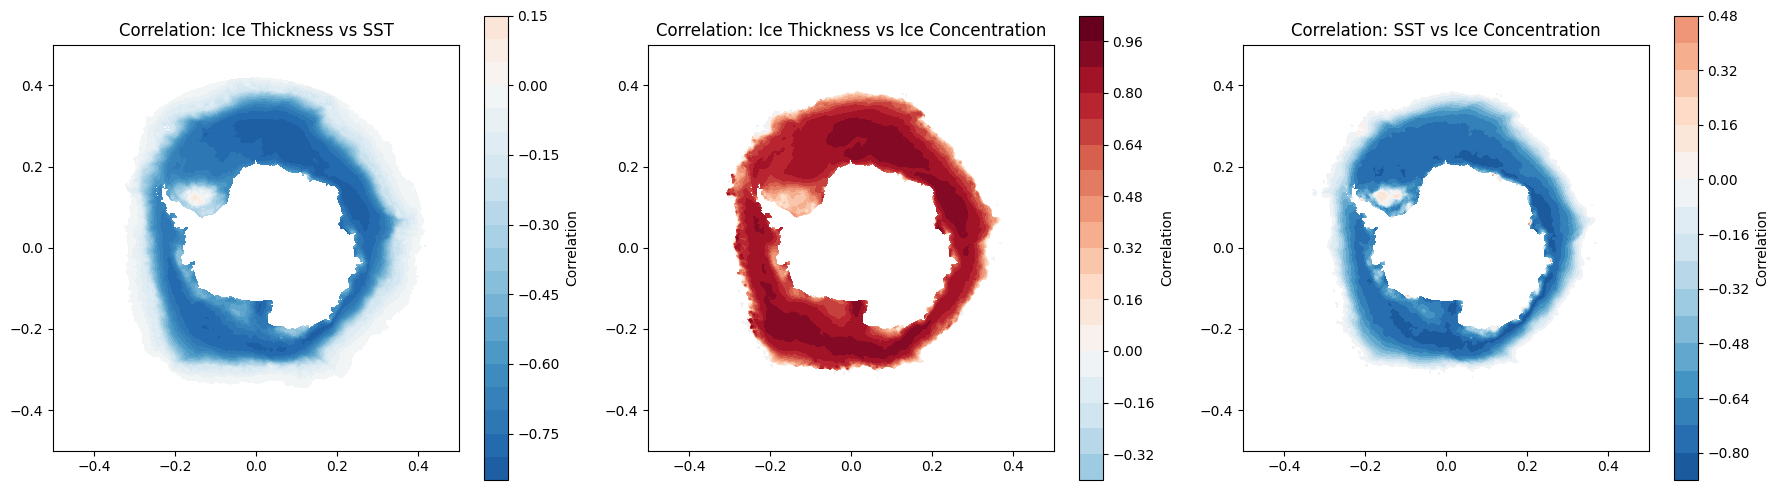

In [16]:
# Visualize correlation maps using plot_data function (adapted for 2D data)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Thickness vs SST
ax = axes[0]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, corr_thickness_sst, np.nan), 
                 cmap='RdBu_r', vmin=-1, vmax=1, levels=20)
ax.set_title('Correlation: Ice Thickness vs SST')
plt.colorbar(cf, ax=ax, label='Correlation')

# Thickness vs Ice Concentration
ax = axes[1]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, corr_thickness_ice, np.nan), 
                 cmap='RdBu_r', vmin=-1, vmax=1, levels=20)
ax.set_title('Correlation: Ice Thickness vs Ice Concentration')
plt.colorbar(cf, ax=ax, label='Correlation')

# SST vs Ice Concentration
ax = axes[2]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, corr_sst_ice, np.nan), 
                 cmap='RdBu_r', vmin=-1, vmax=1, levels=20)
ax.set_title('Correlation: SST vs Ice Concentration')
plt.colorbar(cf, ax=ax, label='Correlation')

plt.tight_layout()
plt.show()

## 3. Temporal Correlation Analysis

Compute overall temporal correlations (basin-averaged).

### Basin-Averaged Temporal Correlations

Here we compute a single correlation value per variable pair by averaging across all ocean pixels:

$$\text{Basin correlation} = \text{Pearson}(t_1^{\text{spatial mean}}, t_2^{\text{spatial mean}})$$

This summarizes the overall relationship strength:
- **+1**: Perfect positive correlation (if one increases, so does the other)
- **0**: No correlation
- **-1**: Perfect negative correlation (inverse relationship)

These correlations are across **all 11,600 daily observations**, making them subject to high autocorrelation and potentially spurious significance (this is why yearly averages are more robust for climate interpretation).

In [17]:
# Compute spatial mean timeseries for each variable (ignoring land pixels)
def spatial_mean_timeseries(data, mask):
    """Compute spatial mean ignoring masked pixels"""
    n_time = data.shape[0]
    ts = np.zeros(n_time)
    for t in range(n_time):
        frame = data[t, :, :]
        valid = ~mask & ~np.isnan(frame)
        ts[t] = np.nanmean(frame[valid])
    return ts

thickness_ts = spatial_mean_timeseries(thickness_full, mask_land)
sst_ts = spatial_mean_timeseries(sst_full, mask_land)
ice_ts = spatial_mean_timeseries(ice_full, mask_land)

# Compute temporal correlations
corr_thick_sst_temporal = np.corrcoef(thickness_ts, sst_ts)[0, 1]
corr_thick_ice_temporal = np.corrcoef(thickness_ts, ice_ts)[0, 1]
corr_sst_ice_temporal = np.corrcoef(sst_ts, ice_ts)[0, 1]

print(f"Temporal Correlations (basin-averaged):")
print(f"  Ice Thickness vs SST: {corr_thick_sst_temporal:.3f}")
print(f"  Ice Thickness vs Ice Concentration: {corr_thick_ice_temporal:.3f}")
print(f"  SST vs Ice Concentration: {corr_sst_ice_temporal:.3f}")

Temporal Correlations (basin-averaged):
  Ice Thickness vs SST: -0.961
  Ice Thickness vs Ice Concentration: 0.979
  SST vs Ice Concentration: -0.978


## 4. Timeseries Visualization

Plot all three variables over time to visualize their evolution.

### Time Series Visualization

These plots show how each variable evolves over the 31-year period at the basin (spatially-averaged) level. Each line represents daily values:
- **Blue (Ice Thickness)**: Oscillates seasonally (thicker in winter, thinner in summer)
- **Red (SST)**: Seasonal pattern with warmest in summer, coldest in winter
- **Cyan (Ice Concentration)**: Maximum extent in winter, minimum in summer

**Key observation**: Annual cycles dominate! Linear trends (if they exist) are small compared to seasonal variation, which is why we need to look at yearly averages to isolate the long-term signal.

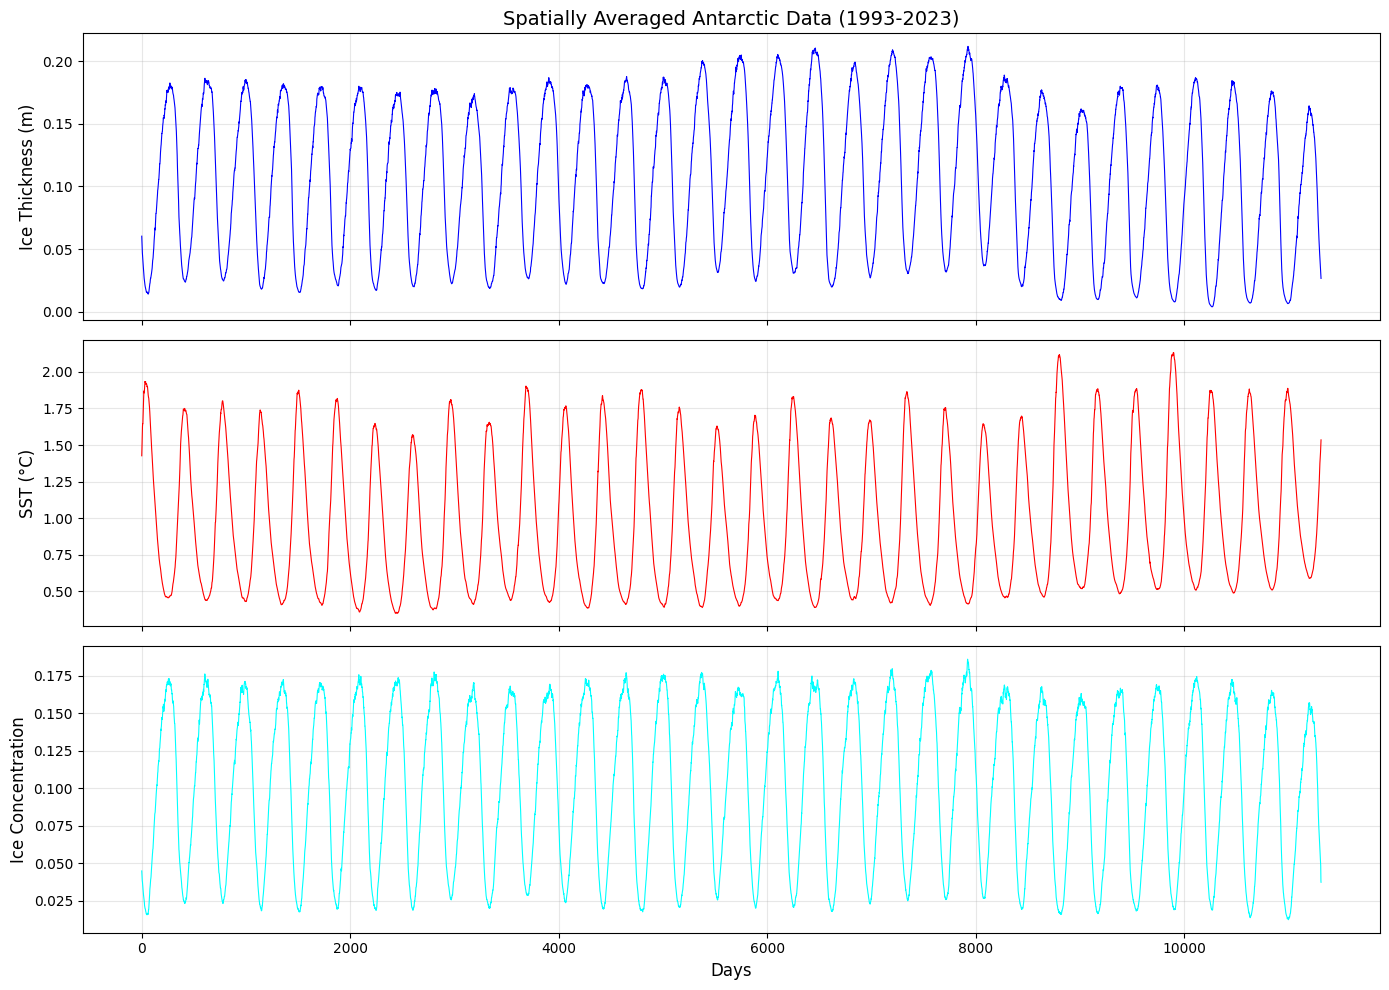

In [18]:
# Create time axis (assuming 365 days per year)
n_days = len(thickness_ts)
n_years = len(thickness_data)
time_axis = np.arange(n_days)

# Plot all three timeseries
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Ice Thickness
axes[0].plot(time_axis, thickness_ts, color='blue', linewidth=0.8)
axes[0].set_ylabel('Ice Thickness (m)', fontsize=12)
axes[0].set_title('Spatially Averaged Antarctic Data (1993-2023)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# SST
axes[1].plot(time_axis, sst_ts, color='red', linewidth=0.8)
axes[1].set_ylabel('SST (°C)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Ice Concentration
axes[2].plot(time_axis, ice_ts, color='cyan', linewidth=0.8)
axes[2].set_ylabel('Ice Concentration', fontsize=12)
axes[2].set_xlabel('Days', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Dual Y-Axis Plots

Plot multiple variables on the same figure to better visualize correlations.

### Correlation at Different Timescales

The dual-axis plots combine two variables on the same figure using different y-axes. This makes it easier to visually assess whether they move together (high correlation) or oppose each other (negative correlation).

These plots use the **full daily timeseries** (11,600 points), which includes all the seasonal noise. Compare these correlations to the yearly-averaged results later—they often tell different stories about the underlying climate dynamics.

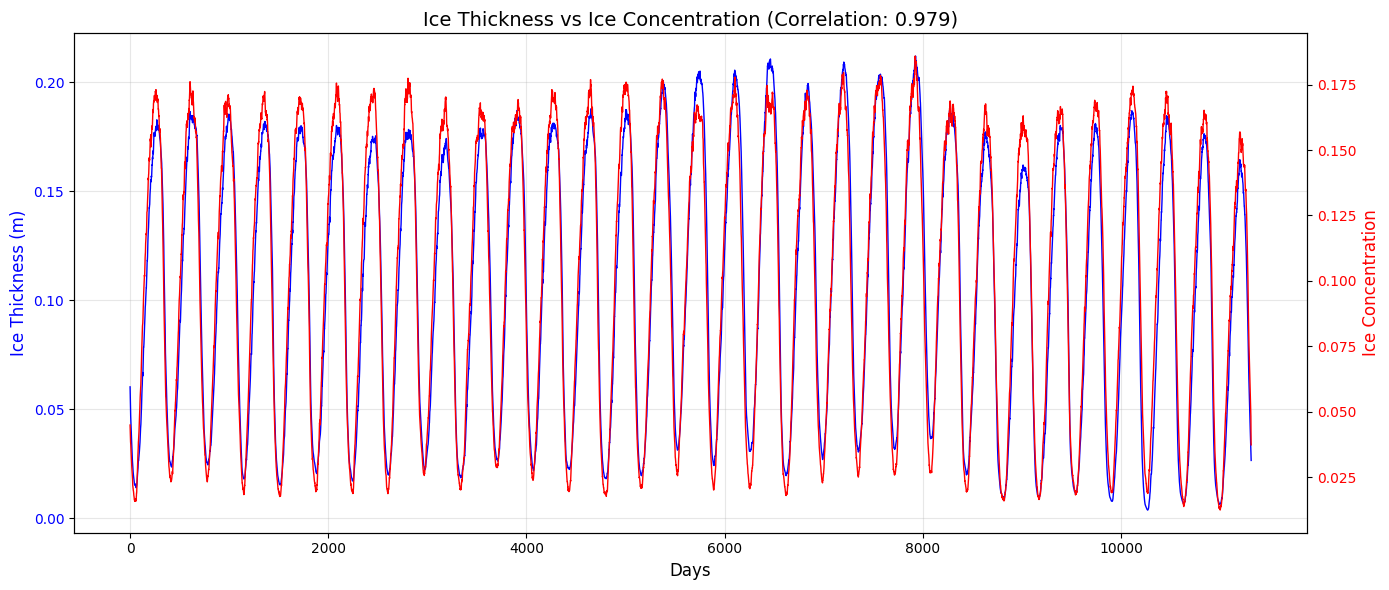

In [19]:
# Plot Ice Thickness and Ice concentration on dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# Ice Thickness on left y-axis
ax1.plot(time_axis, thickness_ts, color='blue', label='Ice Thickness (m)', linewidth=1)
ax1.set_xlabel('Days', fontsize=12)
ax1.set_ylabel('Ice Thickness (m)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# Ice concentration on right y-axis
ax2 = ax1.twinx()
ax2.plot(time_axis, ice_ts, color='red', label='Ice Concentration', linewidth=1)
ax2.set_ylabel('Ice Concentration', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'Ice Thickness vs Ice Concentration (Correlation: {corr_thick_ice_temporal:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

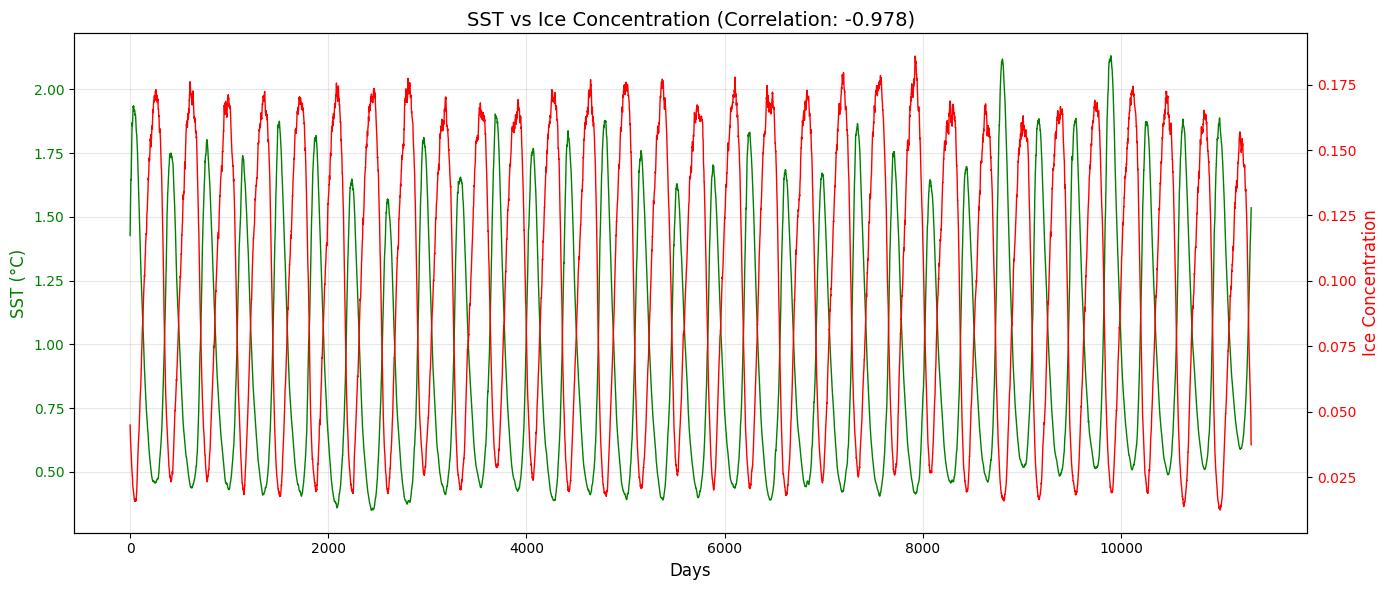

In [20]:
# Plot SST and Ice Concentration on dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# SST on left y-axis
ax1.plot(time_axis, sst_ts, color='green', label='SST (°C)', linewidth=1)
ax1.set_xlabel('Days', fontsize=12)
ax1.set_ylabel('SST (°C)', color='green', fontsize=12)
ax1.tick_params(axis='y', labelcolor='green')
ax1.grid(True, alpha=0.3)

# Ice Concentration on right y-axis
ax2 = ax1.twinx()
ax2.plot(time_axis, ice_ts, color='red', label='Ice Concentration', linewidth=1)
ax2.set_ylabel('Ice Concentration', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title(f'SST vs Ice Concentration (Correlation: {corr_sst_ice_temporal:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Trend Analysis

Compute linear trends for each variable to quantify long-term changes.

### Linear Trend Estimation

We fit first-order polynomials to **yearly-averaged data** to estimate linear change rates:

$$\text{Value} = m \cdot \text{year} + b$$

The slope $m$ is converted to **per-decade units** for climate science conventions:

$$\text{Trend/decade} = m \times 10 \text{ years}$$

**Why yearly averages?** They filter out seasonal cycles and daily noise, revealing only the actual long-term climate signal. Daily data would show inflated trends due to temporal autocorrelation.

**Units:**
- Ice Thickness: m/decade
- SST: °C/decade  
- Ice Concentration: dimensionless/decade (fraction)

In [21]:
# Compute yearly averages for trend analysis
def compute_yearly_means(data_list):
    """Compute yearly mean for each year in the list"""
    return np.array([np.nanmean(year_data) for year_data in data_list])

thickness_yearly = compute_yearly_means(thickness_data)
sst_yearly = compute_yearly_means(sst_data)
ice_yearly = compute_yearly_means(data)

# Create actual years array (1993-2023)
years_index = np.arange(len(thickness_yearly))
years = 1993 + years_index

# Compute linear trends using polyfit (use index for fitting)
thickness_slope, thickness_intercept = np.polyfit(years_index, thickness_yearly, 1)
sst_slope, sst_intercept = np.polyfit(years_index, sst_yearly, 1)
ice_slope, ice_intercept = np.polyfit(years_index, ice_yearly, 1)

# Calculate trends per decade
thickness_trend_decade = thickness_slope * 10
sst_trend_decade = sst_slope * 10
ice_trend_decade = ice_slope * 10

print(f"Linear Trends (per decade):")
print(f"  Ice Thickness: {thickness_trend_decade:.4f} m/decade")

print(f"  SST: {sst_trend_decade:.4f} °C/decade")
print(f"  Ice Concentration: {ice_trend_decade:.4f} /decade")

Linear Trends (per decade):
  Ice Thickness: -0.0034 m/decade
  SST: 0.0371 °C/decade
  Ice Concentration: -0.0020 /decade


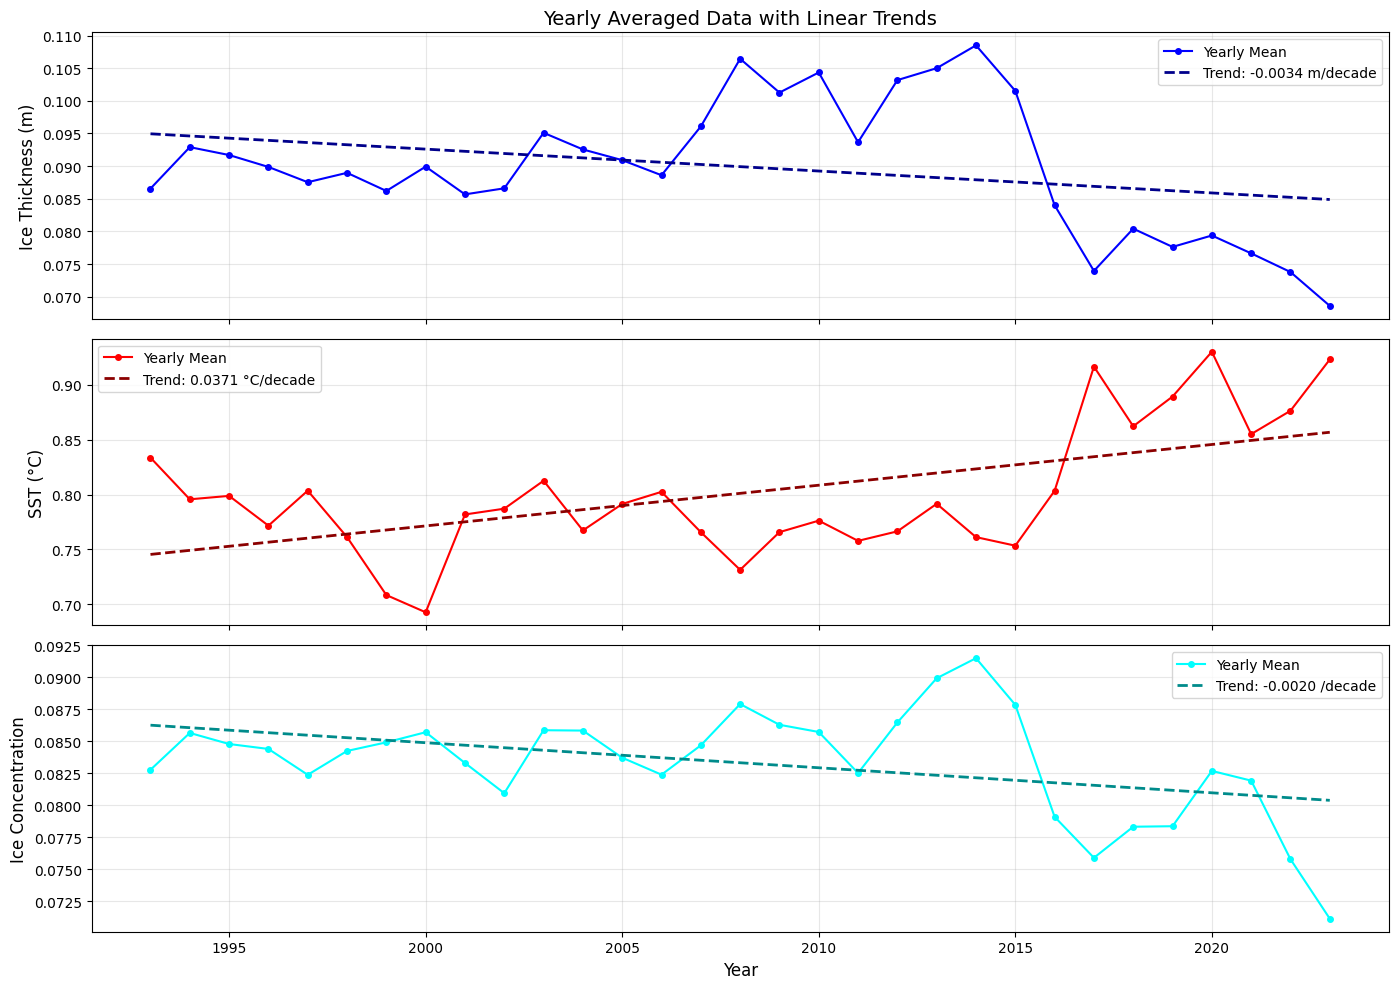

In [22]:
# Plot yearly timeseries with trend lines
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Compute trend lines
thickness_trend = thickness_slope * years_index + thickness_intercept
sst_trend = sst_slope * years_index + sst_intercept
ice_trend = ice_slope * years_index + ice_intercept

# Ice Thickness
axes[0].plot(years, thickness_yearly, 'o-', color='blue', label='Yearly Mean', markersize=4)
axes[0].plot(years, thickness_trend, '--', color='darkblue', linewidth=2, 
             label=f'Trend: {thickness_trend_decade:.4f} m/decade')
axes[0].set_ylabel('Ice Thickness (m)', fontsize=12)
axes[0].set_title('Yearly Averaged Data with Linear Trends', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# SST
axes[1].plot(years, sst_yearly, 'o-', color='red', label='Yearly Mean', markersize=4)
axes[1].plot(years, sst_trend, '--', color='darkred', linewidth=2, 
             label=f'Trend: {sst_trend_decade:.4f} °C/decade')
axes[1].set_ylabel('SST (°C)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Ice Concentration
axes[2].plot(years, ice_yearly, 'o-', color='cyan', label='Yearly Mean', markersize=4)
axes[2].plot(years, ice_trend, '--', color='darkcyan', linewidth=2, 
             label=f'Trend: {ice_trend_decade:.4f} /decade')
axes[2].set_ylabel('Ice Concentration', fontsize=12)
axes[2].set_xlabel('Year', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Spatial Trend Maps

Compute pixel-wise trends to see how changes vary spatially across the Antarctic region.

### Pixel-by-Pixel Spatial Trends

These maps show where trends are **increasing** (red) vs **decreasing** (blue) across the Antarctic region. Unlike the basin-average trend (one number), these maps reveal spatial heterogeneity:
- **Uniform colors**: Trend is consistent across the region
- **Mixed colors**: Different parts of Antarctica have opposite trends
- **White/gaps**: Areas with insufficient data or land

This reveals important regional climate dynamics: Is warming/cooling happening everywhere equally, or are there regional hotspots?

In [23]:
def compute_spatial_trends(data_list, mask):
    """
    Compute pixel-wise linear trends from yearly data
    
    Args:
        data_list: List of yearly arrays, each of shape (n_days, ny, nx)
        mask: Boolean mask (True where land)
    
    Returns:
        Trend map (slope per year) of shape (ny, nx)
    """
    # First compute yearly means for each pixel
    n_years = len(data_list)
    ny, nx = data_list[0].shape[1], data_list[0].shape[2]
    
    yearly_data = np.zeros((n_years, ny, nx))
    for year_idx, year_data in enumerate(data_list):
        yearly_data[year_idx, :, :] = np.nanmean(year_data, axis=0)
    
    # Compute trends at each pixel
    trend_map = np.full((ny, nx), np.nan)
    years = np.arange(n_years)
    
    for i in range(ny):
        for j in range(nx):
            if mask is not None and mask[i, j]:
                continue
            
            ts = yearly_data[:, i, j]
            if np.sum(~np.isnan(ts)) > n_years * 0.5:  # Need at least 50% valid data
                slope, _ = np.polyfit(years[~np.isnan(ts)], ts[~np.isnan(ts)], 1)
                trend_map[i, j] = slope * 10  # Convert to per decade
    
    return trend_map

print("Computing spatial trends (this may take a minute)...")
thickness_trend_map = compute_spatial_trends(thickness_data, mask_land)
sst_trend_map = compute_spatial_trends(sst_data, mask_land)
ice_trend_map = compute_spatial_trends(data, mask_land)
print("Done!")

Computing spatial trends (this may take a minute)...
Done!


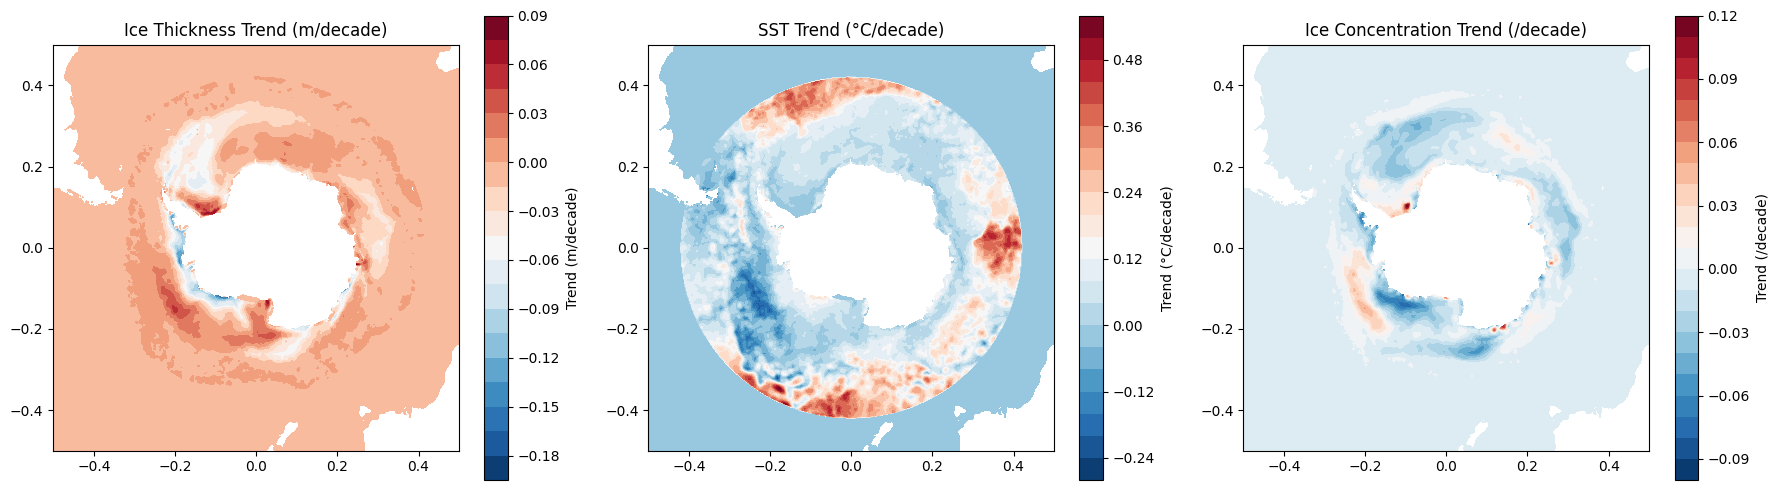

In [24]:
# Plot spatial trend maps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ice Thickness Trend
ax = axes[0]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, thickness_trend_map, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('Ice Thickness Trend (m/decade)')
plt.colorbar(cf, ax=ax, label='Trend (m/decade)')

# SST Trend
ax = axes[1]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, sst_trend_map, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('SST Trend (°C/decade)')
plt.colorbar(cf, ax=ax, label='Trend (°C/decade)')

# Ice Concentration Trend
ax = axes[2]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, ice_trend_map, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('Ice Concentration Trend (/decade)')
plt.colorbar(cf, ax=ax, label='Trend (/decade)')

plt.tight_layout()
plt.show()

## 8. Summary Statistics

Print key findings from the correlation and trend analysis.

### Analysis Summary

This summary table consolidates key findings:

1. **Temporal Correlations**: How closely linked are the basin-averaged timeseries?
   - Interpreted from **daily data** (high autocorrelation)
   - Use with caution: may exaggerate relationships

2. **Linear Trends (per decade)**: Rate of long-term change
   - Computed from **yearly data** (more robust)
   - Directly comparable to climate model projections

3. **Spatial Statistics**: How consistent are trends across regions?
   - Wide ranges indicate heterogeneous response
   - Narrow ranges indicate uniform trends

In [25]:
print("="*70)
print("ANTARCTIC DATA ANALYSIS SUMMARY (1993-2023)")
print("="*70)
print()
print("TEMPORAL CORRELATIONS (basin-averaged):")
print(f"  Ice Thickness ↔ SST:              {corr_thick_sst_temporal:+.3f}")
print(f"  Ice Thickness ↔ Ice Concentration: {corr_thick_ice_temporal:+.3f}")
print(f"  SST ↔ Ice Concentration:          {corr_sst_ice_temporal:+.3f}")
print()
print("LINEAR TRENDS (per decade):")
print(f"  Ice Thickness:      {thickness_trend_decade:+.4f} m/decade")
print(f"  SST:                {sst_trend_decade:+.4f} °C/decade")
print(f"  Ice Concentration:  {ice_trend_decade:+.4f} /decade")
print()
print("SPATIAL STATISTICS:")
print(f"  Ice Thickness trend range:      [{np.nanmin(thickness_trend_map):.4f}, {np.nanmax(thickness_trend_map):.4f}] m/decade")
print(f"  SST trend range:                [{np.nanmin(sst_trend_map):.4f}, {np.nanmax(sst_trend_map):.4f}] °C/decade")
print(f"  Ice Concentration trend range:  [{np.nanmin(ice_trend_map):.4f}, {np.nanmax(ice_trend_map):.4f}] /decade")
print()
print("="*70)

ANTARCTIC DATA ANALYSIS SUMMARY (1993-2023)

TEMPORAL CORRELATIONS (basin-averaged):
  Ice Thickness ↔ SST:              -0.961
  Ice Thickness ↔ Ice Concentration: +0.979
  SST ↔ Ice Concentration:          -0.978

LINEAR TRENDS (per decade):
  Ice Thickness:      -0.0034 m/decade
  SST:                +0.0371 °C/decade
  Ice Concentration:  -0.0020 /decade

SPATIAL STATISTICS:
  Ice Thickness trend range:      [-0.1811, 0.0827] m/decade
  SST trend range:                [-0.2439, 0.5433] °C/decade
  Ice Concentration trend range:  [-0.0904, 0.1144] /decade



## 9. Empirical Orthogonal Functions (EOF Analysis)

EOF analysis identifies the dominant spatial patterns of variability in the data. This is analogous to PCA but applied to spatiotemporal climate data.

- **EOF modes**: Spatial patterns that explain variance
- **Principal Components (PCs)**: Temporal evolution of each mode
- **Variance explained**: How much of the total variability each mode captures

  Compute EOF analysis on spatiotemporal data
    
    Args:
        data: Array of shape (n_time, ny, nx)
        mask: Boolean mask (True where land)
        n_modes: Number of EOF modes to compute
        detrend: Whether to remove temporal mean before EOF
    
    Returns:
        eofs: Spatial patterns (n_modes, ny, nx)
        pcs: Principal components (n_time, n_modes)
        var_explained: Variance explained by each mode (%)

In [26]:
"""from sklearn.decomposition import PCA

def compute_eofs(data, mask, n_modes=3, detrend=True):
    n_time, ny, nx = data.shape
    
    # Reshape to (n_time, n_pixels)
    data_flat = data.reshape(n_time, ny * nx)
    
    # Create mask for valid pixels (not land, not all NaN)
    mask_flat = mask.reshape(-1)
    valid_pixels = ~mask_flat & ~np.isnan(data_flat).all(axis=0)
    
    # Extract valid data
    data_valid = data_flat[:, valid_pixels]
    
    # Remove temporal mean (anomalies)
    if detrend:
        data_mean = np.nanmean(data_valid, axis=0)
        data_valid = data_valid - data_mean
    
    # Handle NaN values (replace with column mean)
    col_means = np.nanmean(data_valid, axis=0)
    for i in range(data_valid.shape[1]):
        data_valid[np.isnan(data_valid[:, i]), i] = col_means[i]
    
    # Perform PCA (EOF analysis)
    pca = PCA(n_components=n_modes)
    pcs = pca.fit_transform(data_valid)
    
    # Variance explained
    var_explained = pca.explained_variance_ratio_ * 100
    
    # Reconstruct EOF spatial patterns
    eofs = np.full((n_modes, ny, nx), np.nan)
    eof_components = pca.components_  # Shape: (n_modes, n_valid_pixels)
    
    for mode in range(n_modes):
        eof_flat = np.full(ny * nx, np.nan)
        eof_flat[valid_pixels] = eof_components[mode, :]
        eofs[mode, :, :] = eof_flat.reshape(ny, nx)
    
    return eofs, pcs, var_explained"""

'from sklearn.decomposition import PCA\n\ndef compute_eofs(data, mask, n_modes=3, detrend=True):\n    n_time, ny, nx = data.shape\n    \n    # Reshape to (n_time, n_pixels)\n    data_flat = data.reshape(n_time, ny * nx)\n    \n    # Create mask for valid pixels (not land, not all NaN)\n    mask_flat = mask.reshape(-1)\n    valid_pixels = ~mask_flat & ~np.isnan(data_flat).all(axis=0)\n    \n    # Extract valid data\n    data_valid = data_flat[:, valid_pixels]\n    \n    # Remove temporal mean (anomalies)\n    if detrend:\n        data_mean = np.nanmean(data_valid, axis=0)\n        data_valid = data_valid - data_mean\n    \n    # Handle NaN values (replace with column mean)\n    col_means = np.nanmean(data_valid, axis=0)\n    for i in range(data_valid.shape[1]):\n        data_valid[np.isnan(data_valid[:, i]), i] = col_means[i]\n    \n    # Perform PCA (EOF analysis)\n    pca = PCA(n_components=n_modes)\n    pcs = pca.fit_transform(data_valid)\n    \n    # Variance explained\n    var_expl

In [27]:
"""# Compute EOFs for all three variables
print("Computing EOF analysis...")
print("\nIce Thickness:")
thickness_eofs, thickness_pcs, thickness_var = compute_eofs(thickness_full, mask_land, n_modes=3)
print(f"  EOF 1: {thickness_var[0]:.2f}% variance")
print(f"  EOF 2: {thickness_var[1]:.2f}% variance")
print(f"  EOF 3: {thickness_var[2]:.2f}% variance")"""

'# Compute EOFs for all three variables\nprint("Computing EOF analysis...")\nprint("\nIce Thickness:")\nthickness_eofs, thickness_pcs, thickness_var = compute_eofs(thickness_full, mask_land, n_modes=3)\nprint(f"  EOF 1: {thickness_var[0]:.2f}% variance")\nprint(f"  EOF 2: {thickness_var[1]:.2f}% variance")\nprint(f"  EOF 3: {thickness_var[2]:.2f}% variance")'

In [28]:
"""print("\nSST:")
sst_eofs, sst_pcs, sst_var = compute_eofs(sst_full, mask_land, n_modes=3)
print(f"  EOF 1: {sst_var[0]:.2f}% variance")
print(f"  EOF 2: {sst_var[1]:.2f}% variance")
print(f"  EOF 3: {sst_var[2]:.2f}% variance")"""

'print("\nSST:")\nsst_eofs, sst_pcs, sst_var = compute_eofs(sst_full, mask_land, n_modes=3)\nprint(f"  EOF 1: {sst_var[0]:.2f}% variance")\nprint(f"  EOF 2: {sst_var[1]:.2f}% variance")\nprint(f"  EOF 3: {sst_var[2]:.2f}% variance")'

In [29]:
"""print("\nIce Concentration:")
ice_eofs, ice_pcs, ice_var = compute_eofs(ice_full, mask_land, n_modes=3)
print(f"  EOF 1: {ice_var[0]:.2f}% variance")
print(f"  EOF 2: {ice_var[1]:.2f}% variance")
print(f"  EOF 3: {ice_var[2]:.2f}% variance")

print("\nDone!")"""

'print("\nIce Concentration:")\nice_eofs, ice_pcs, ice_var = compute_eofs(ice_full, mask_land, n_modes=3)\nprint(f"  EOF 1: {ice_var[0]:.2f}% variance")\nprint(f"  EOF 2: {ice_var[1]:.2f}% variance")\nprint(f"  EOF 3: {ice_var[2]:.2f}% variance")\n\nprint("\nDone!")'

In [30]:
"""# Visualize EOF spatial patterns for Ice Thickness
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    ax = axes[i]
    ax.set(adjustable='box', aspect=1)
    
    # Normalize EOF for better visualization
    eof_data = thickness_eofs[i, :, :]
    vmax = np.nanmax(np.abs(eof_data))
    
    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), 
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)
    ax.set_title(f'Ice Thickness EOF {i+1} ({thickness_var[i]:.1f}% variance)')
    plt.colorbar(cf, ax=ax, label='EOF Loading')

plt.tight_layout()
plt.show()

# Plot Principal Components (temporal evolution)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i in range(3):
    axes[i].plot(time_axis, thickness_pcs[:, i], linewidth=0.8)
    axes[i].set_ylabel(f'PC {i+1}', fontsize=12)
    axes[i].set_title(f'Ice Thickness PC {i+1} ({thickness_var[i]:.1f}% variance)', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(0, color='black', linewidth=0.5, linestyle='--')

axes[2].set_xlabel('Days', fontsize=12)
plt.tight_layout()
plt.show()"""

"# Visualize EOF spatial patterns for Ice Thickness\nfig, axes = plt.subplots(1, 3, figsize=(18, 5))\n\nfor i in range(3):\n    ax = axes[i]\n    ax.set(adjustable='box', aspect=1)\n    \n    # Normalize EOF for better visualization\n    eof_data = thickness_eofs[i, :, :]\n    vmax = np.nanmax(np.abs(eof_data))\n    \n    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), \n                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)\n    ax.set_title(f'Ice Thickness EOF {i+1} ({thickness_var[i]:.1f}% variance)')\n    plt.colorbar(cf, ax=ax, label='EOF Loading')\n\nplt.tight_layout()\nplt.show()\n\n# Plot Principal Components (temporal evolution)\nfig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)\n\nfor i in range(3):\n    axes[i].plot(time_axis, thickness_pcs[:, i], linewidth=0.8)\n    axes[i].set_ylabel(f'PC {i+1}', fontsize=12)\n    axes[i].set_title(f'Ice Thickness PC {i+1} ({thickness_var[i]:.1f}% variance)', fontsize=12)\n    axes[i].grid(True, al

In [31]:
"""# Visualize EOF spatial patterns for SST
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    ax = axes[i]
    ax.set(adjustable='box', aspect=1)
    
    eof_data = sst_eofs[i, :, :]
    vmax = np.nanmax(np.abs(eof_data))
    
    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), 
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)
    ax.set_title(f'SST EOF {i+1} ({sst_var[i]:.1f}% variance)')
    plt.colorbar(cf, ax=ax, label='EOF Loading')

plt.tight_layout()
plt.show()

# Visualize EOF spatial patterns for Ice Concentration
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    ax = axes[i]
    ax.set(adjustable='box', aspect=1)
    
    eof_data = ice_eofs[i, :, :]
    vmax = np.nanmax(np.abs(eof_data))
    
    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), 
                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)
    ax.set_title(f'Ice Concentration EOF {i+1} ({ice_var[i]:.1f}% variance)')
    plt.colorbar(cf, ax=ax, label='EOF Loading')

plt.tight_layout()
plt.show()"""

"# Visualize EOF spatial patterns for SST\nfig, axes = plt.subplots(1, 3, figsize=(18, 5))\n\nfor i in range(3):\n    ax = axes[i]\n    ax.set(adjustable='box', aspect=1)\n    \n    eof_data = sst_eofs[i, :, :]\n    vmax = np.nanmax(np.abs(eof_data))\n    \n    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), \n                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)\n    ax.set_title(f'SST EOF {i+1} ({sst_var[i]:.1f}% variance)')\n    plt.colorbar(cf, ax=ax, label='EOF Loading')\n\nplt.tight_layout()\nplt.show()\n\n# Visualize EOF spatial patterns for Ice Concentration\nfig, axes = plt.subplots(1, 3, figsize=(18, 5))\n\nfor i in range(3):\n    ax = axes[i]\n    ax.set(adjustable='box', aspect=1)\n    \n    eof_data = ice_eofs[i, :, :]\n    vmax = np.nanmax(np.abs(eof_data))\n    \n    cf = ax.contourf(x, y, np.where(~mask_land, eof_data, np.nan), \n                     cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)\n    ax.set_title(f'Ice Concentration EOF

## 10. Mann-Kendall Trend Test

The Mann-Kendall test is a non-parametric statistical test used to detect monotonic trends in time series data. Unlike linear regression, it doesn't assume the data is normally distributed.

- **Null hypothesis (H₀)**: No monotonic trend exists
- **Test statistic (S)**: Measures the direction and strength of trend
- **p-value**: Probability of observing the data if H₀ is true (typically reject H₀ if p < 0.05)
- **Trend interpretation**:
  - p < 0.05: Statistically significant trend
  - p ≥ 0.05: No significant trend detected

### What is the Mann-Kendall Test?

The Mann-Kendall test is a **non-parametric trend test** that asks: "Is this time series monotonically increasing or decreasing?"

**Why non-parametric?** It doesn't assume normal distribution. Instead, it counts whether later values tend to be larger or smaller than earlier values.

**Key statistics:**
- **S-statistic**: Counts concordant vs discordant pairs (positive S = increasing trend)
- **p-value**: Probability that this trend occurs by random chance
  - **p < 0.05**: Trend is statistically significant (unlikely to be random)
  - **p ≥ 0.05**: Trend could be noise; no clear evidence of monotonic change
- **Kendall's τ (tau)**: Normalized trend strength
  - τ ≈ +1: Strong increasing trend
  - τ ≈ -1: Strong decreasing trend
  - τ ≈ 0: No trend

**Critical insight**: This notebook tests **two different timescales**:
1. **Daily basin-average** (11,600 points): Often shows spurious significance due to autocorrelation
2. **Yearly averages** (31 points): More conservative, reflects true climate signal

⚠️ **Important**: When basin-average shows significance but yearly-average doesn't, the daily trend is **likely an artifact of autocorrelation**, not a robust climate trend.

In [32]:
from scipy import stats

def mann_kendall_test(data):
    """
    Perform Mann-Kendall trend test
    
    Args:
        data: 1D array of time series data
    
    Returns:
        trend: 'increasing', 'decreasing', or 'no trend'
        p_value: Statistical significance
        S: Mann-Kendall statistic
        tau: Kendall's tau (normalized trend indicator)
    """
    n = len(data)
    
    # Remove NaN values
    data_clean = data[~np.isnan(data)]
    n = len(data_clean)
    
    if n < 3:
        return 'insufficient data', np.nan, np.nan, np.nan
    
    # Calculate S statistic
    S = 0
    for i in range(n-1):
        for j in range(i+1, n):
            S += np.sign(data_clean[j] - data_clean[i])
    
    # Calculate variance of S
    var_S = n * (n - 1) * (2 * n + 5) / 18
    
    # Calculate normalized test statistic Z
    if S > 0:
        Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(var_S)
    else:
        Z = 0
    
    # Calculate p-value (two-tailed test)
    p_value = 2 * (1 - stats.norm.cdf(abs(Z)))
    
    # Kendall's tau
    tau = S / (0.5 * n * (n - 1))
    
    # Determine trend
    alpha = 0.05  # Significance level
    if p_value < alpha:
        if S > 0:
            trend = 'increasing'
        else:
            trend = 'decreasing'
    else:
        trend = 'no trend'
    
    return trend, p_value, S, tau

# Apply Mann-Kendall test to basin-averaged timeseries
print("="*70)
print("MANN-KENDALL TREND TEST RESULTS (Basin-Averaged)")
print("="*70)
print()

# Ice Thickness
trend, p_val, S, tau = mann_kendall_test(thickness_ts)
print("ICE THICKNESS:")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")
print(f"  Kendall τ:  {tau:.4f}")
print()

# SST
trend, p_val, S, tau = mann_kendall_test(sst_ts)
print("SEA SURFACE TEMPERATURE:")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")
print(f"  Kendall τ:  {tau:.4f}")
print()

# Ice Concentration
trend, p_val, S, tau = mann_kendall_test(ice_ts)
print("ICE CONCENTRATION:")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant)' if p_val < 0.05 else '(not significant)'}")
print(f"  Kendall τ:  {tau:.4f}")
print()
print("="*70)

MANN-KENDALL TREND TEST RESULTS (Basin-Averaged)

ICE THICKNESS:
  Trend:      decreasing
  p-value:    0.0007 (significant)
  Kendall τ:  -0.0212

SEA SURFACE TEMPERATURE:
  Trend:      increasing
  p-value:    0.0000 (significant)
  Kendall τ:  0.0560

ICE CONCENTRATION:
  Trend:      decreasing
  p-value:    0.0085 (significant)
  Kendall τ:  -0.0165



In [33]:
# Apply Mann-Kendall test to yearly averaged data for better interpretation
print("="*70)
print("MANN-KENDALL TREND TEST RESULTS (Yearly Averages)")
print("="*70)
print()

# Ice Thickness (yearly)
trend, p_val, S, tau = mann_kendall_test(thickness_yearly)
print("ICE THICKNESS (Yearly Average):")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant ✓)' if p_val < 0.05 else '(not significant ✗)'}")
print(f"  Kendall τ:  {tau:.4f}")
print(f"  Linear trend: {thickness_trend_decade:.4f} m/decade")
print()

# SST (yearly)
trend, p_val, S, tau = mann_kendall_test(sst_yearly)
print("SEA SURFACE TEMPERATURE (Yearly Average):")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant ✓)' if p_val < 0.05 else '(not significant ✗)'}")
print(f"  Kendall τ:  {tau:.4f}")
print(f"  Linear trend: {sst_trend_decade:.4f} °C/decade")
print()

# Ice Concentration (yearly)
trend, p_val, S, tau = mann_kendall_test(ice_yearly)
print("ICE CONCENTRATION (Yearly Average):")
print(f"  Trend:      {trend}")
print(f"  p-value:    {p_val:.4f} {'(significant ✓)' if p_val < 0.05 else '(not significant ✗)'}")
print(f"  Kendall τ:  {tau:.4f}")
print(f"  Linear trend: {ice_trend_decade:.4f} /decade")
print()
print("="*70)
print("\nInterpretation:")
print("- Kendall τ close to +1: Strong increasing trend")
print("- Kendall τ close to -1: Strong decreasing trend")
print("- Kendall τ close to 0:  No trend")
print("- p-value < 0.05:        Trend is statistically significant")

MANN-KENDALL TREND TEST RESULTS (Yearly Averages)

ICE THICKNESS (Yearly Average):
  Trend:      no trend
  p-value:    0.2478 (not significant ✗)
  Kendall τ:  -0.1484
  Linear trend: -0.0034 m/decade

SEA SURFACE TEMPERATURE (Yearly Average):
  Trend:      no trend
  p-value:    0.0527 (not significant ✗)
  Kendall τ:  0.2473
  Linear trend: 0.0371 °C/decade

ICE CONCENTRATION (Yearly Average):
  Trend:      no trend
  p-value:    0.1849 (not significant ✗)
  Kendall τ:  -0.1699
  Linear trend: -0.0020 /decade


Interpretation:
- Kendall τ close to +1: Strong increasing trend
- Kendall τ close to -1: Strong decreasing trend
- Kendall τ close to 0:  No trend
- p-value < 0.05:        Trend is statistically significant


In [34]:
# Compute spatial Mann-Kendall test (p-value map showing where trends are significant)
def compute_spatial_mann_kendall(data_list, mask):
    """
    Compute Mann-Kendall test at each pixel
    
    Returns:
        p_value_map: p-values at each pixel
        trend_map: Trend direction at each pixel (1=increasing, -1=decreasing, 0=no trend)
    """
    n_years = len(data_list)
    ny, nx = data_list[0].shape[1], data_list[0].shape[2]
    
    # Compute yearly means
    yearly_data = np.zeros((n_years, ny, nx))
    for year_idx, year_data in enumerate(data_list):
        yearly_data[year_idx, :, :] = np.nanmean(year_data, axis=0)
    
    p_value_map = np.full((ny, nx), np.nan)
    trend_map = np.full((ny, nx), np.nan)
    
    for i in range(ny):
        for j in range(nx):
            if mask is not None and mask[i, j]:
                continue
            
            ts = yearly_data[:, i, j]
            if np.sum(~np.isnan(ts)) > n_years * 0.5:
                trend, p_val, S, tau = mann_kendall_test(ts)
                p_value_map[i, j] = p_val
                
                if trend == 'increasing':
                    trend_map[i, j] = 1
                elif trend == 'decreasing':
                    trend_map[i, j] = -1
                else:
                    trend_map[i, j] = 0
    
    return p_value_map, trend_map

print("Computing spatial Mann-Kendall tests (this may take 1-2 minutes)...")
thickness_pval_map, thickness_trend_dir = compute_spatial_mann_kendall(thickness_data, mask_land)
sst_pval_map, sst_trend_dir = compute_spatial_mann_kendall(sst_data, mask_land)
ice_pval_map, ice_trend_dir = compute_spatial_mann_kendall(data, mask_land)
print("Done!")

Computing spatial Mann-Kendall tests (this may take 1-2 minutes)...
Done!


### Spatial Mann-Kendall: Where Are Trends Significant?

These visualizations answer: **"In which parts of Antarctica are trends statistically significant?"**

**Two-row approach:**
1. **Top row (p-value maps)**: Show where significance threshold is met
   - Green (p < 0.05): Statistically significant trend
   - Yellow (0.05 < p < 0.1): Marginally significant
   - Red (p > 0.1): No significant trend

2. **Bottom row (masked trends)**: Show only significant trends
   - Red regions: Significant warming/increasing trends
   - Blue regions: Significant cooling/decreasing trends
   - White/gaps: Insignificant trends (masked out)

**Summary statistics show the percentage of pixels** with significant trends—this quantifies how widespread the climate signal is across the region.

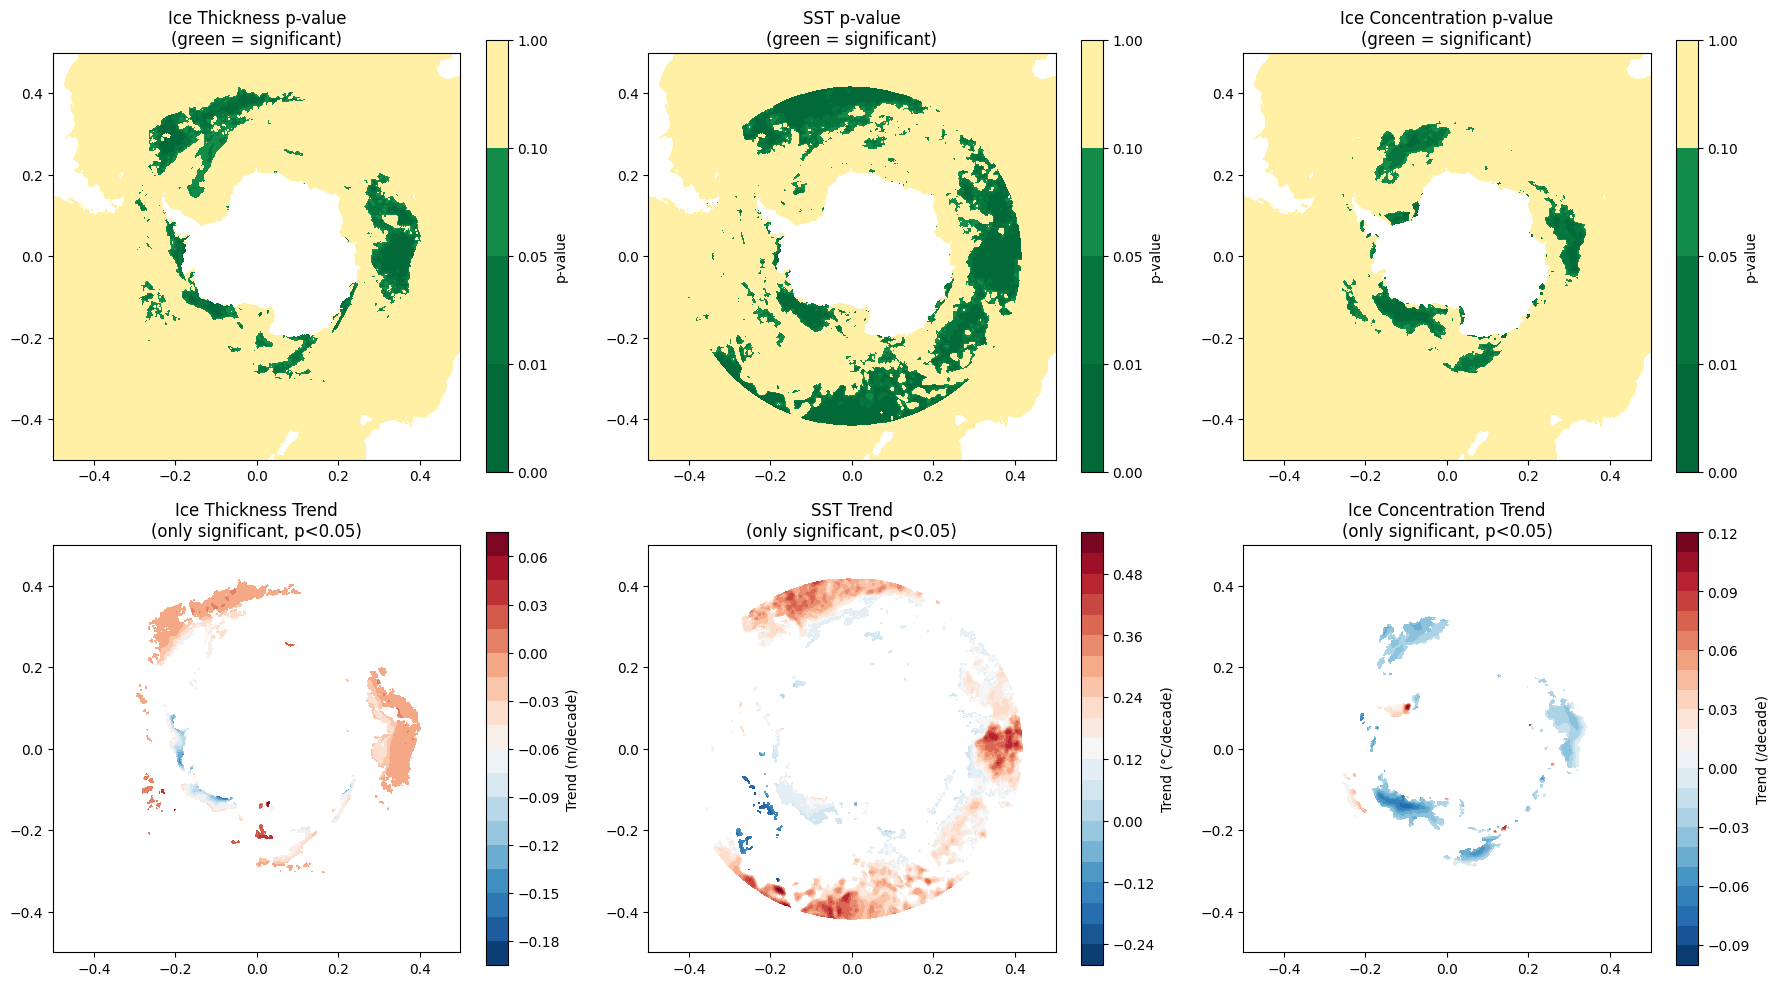


SPATIAL MANN-KENDALL SUMMARY:

Ice Thickness:
  Pixels with significant trend (p<0.05): 6.9%
  Pixels with highly significant trend (p<0.01): 2.9%

SST:
  Pixels with significant trend (p<0.05): 16.8%
  Pixels with highly significant trend (p<0.01): 10.5%

Ice Concentration:
  Pixels with significant trend (p<0.05): 4.4%
  Pixels with highly significant trend (p<0.01): 1.5%


In [35]:
# Visualize statistical significance of trends
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: p-value maps (where trends are significant)
# Ice Thickness
ax = axes[0, 0]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, thickness_pval_map, np.nan), 
                 cmap='RdYlGn_r', levels=[0, 0.01, 0.05, 0.1, 1.0])
ax.set_title('Ice Thickness p-value\n(green = significant)')
plt.colorbar(cf, ax=ax, label='p-value')

# SST
ax = axes[0, 1]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, sst_pval_map, np.nan), 
                 cmap='RdYlGn_r', levels=[0, 0.01, 0.05, 0.1, 1.0])
ax.set_title('SST p-value\n(green = significant)')
plt.colorbar(cf, ax=ax, label='p-value')

# Ice Concentration
ax = axes[0, 2]
ax.set(adjustable='box', aspect=1)
cf = ax.contourf(x, y, np.where(~mask_land, ice_pval_map, np.nan), 
                 cmap='RdYlGn_r', levels=[0, 0.01, 0.05, 0.1, 1.0])
ax.set_title('Ice Concentration p-value\n(green = significant)')
plt.colorbar(cf, ax=ax, label='p-value')

# Row 2: Significant trends only (mask out non-significant)
# Ice Thickness
ax = axes[1, 0]
ax.set(adjustable='box', aspect=1)
significant = thickness_pval_map < 0.05
trend_sig = np.where(significant, thickness_trend_map, np.nan)
cf = ax.contourf(x, y, np.where(~mask_land, trend_sig, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('Ice Thickness Trend\n(only significant, p<0.05)')
plt.colorbar(cf, ax=ax, label='Trend (m/decade)')

# SST
ax = axes[1, 1]
ax.set(adjustable='box', aspect=1)
significant = sst_pval_map < 0.05
trend_sig = np.where(significant, sst_trend_map, np.nan)
cf = ax.contourf(x, y, np.where(~mask_land, trend_sig, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('SST Trend\n(only significant, p<0.05)')
plt.colorbar(cf, ax=ax, label='Trend (°C/decade)')

# Ice Concentration
ax = axes[1, 2]
ax.set(adjustable='box', aspect=1)
significant = ice_pval_map < 0.05
trend_sig = np.where(significant, ice_trend_map, np.nan)
cf = ax.contourf(x, y, np.where(~mask_land, trend_sig, np.nan), 
                 cmap='RdBu_r', levels=20)
ax.set_title('Ice Concentration Trend\n(only significant, p<0.05)')
plt.colorbar(cf, ax=ax, label='Trend (/decade)')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSPATIAL MANN-KENDALL SUMMARY:")
print("="*70)
for name, pval_map in [('Ice Thickness', thickness_pval_map), 
                        ('SST', sst_pval_map), 
                        ('Ice Concentration', ice_pval_map)]:
    valid = ~np.isnan(pval_map)
    sig_05 = (pval_map < 0.05) & valid
    sig_01 = (pval_map < 0.01) & valid
    
    pct_05 = 100 * sig_05.sum() / valid.sum()
    pct_01 = 100 * sig_01.sum() / valid.sum()
    
    print(f"\n{name}:")
    print(f"  Pixels with significant trend (p<0.05): {pct_05:.1f}%")
    print(f"  Pixels with highly significant trend (p<0.01): {pct_01:.1f}%")